## Autor: David Roca Tauste

# ACTIVIDAD 6
---

# ENTREGA 13

In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from collections import OrderedDict
from sklearn import datasets
from sklearn.preprocessing import label_binarize, LabelBinarizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

DISPLAY_PRECISION = 4
pd.set_option("display.precision", DISPLAY_PRECISION)

# PASO 2.1

# Imprimimos las descripciones
datos = pd.read_csv("alumnos.csv", delimiter=";")

# Mostramos información del dataset
print("Primeras filas del dataset:")
print(datos.head())

print("\nInformación del dataset:")
print(datos.info())

print("\nEstadísticas descriptivas:")
print(datos.describe())


Primeras filas del dataset:
      NOMBRE  EDAD  PESO_KG  ALTURA_CM  NUM_HERMANOS  HS_DEPORTE  \
0   JOROSROD    54       86        155             0           5   
1  ROBRIPCON    21       78        178             0          12   
2   SAARTLOP    19       70        181             0           0   
3     RARAES    21       73        180             2           5   
4   DAROCTAU    19       70        174             1           6   

   HS_VIDEOJUEGOS  TALLA_PIE  GENERO_MASCULINO  MIOPÍA  LLEVA_GAFAS  \
0               0         42                 1    5.25            1   
1               6         43                 1    1.00            1   
2               4         44                 1    0.00            0   
3               4         44                 1    0.00            0   
4               6         44                 0    3.00            1   

   TIENE_ALERGIAS  PIEZAS_FRUTA_DÍA  CAFÉS_DIA  
0               0                 3          5  
1               0                 2   

In [2]:
# PASO 2.2

RATIO_PARA_TEST = 0.2

# Eligimos el target y excluimos el NOMBRE y la columna objetivo
TARGET = "LLEVA_GAFAS"
X = datos.drop(columns=["NOMBRE", TARGET])
y = datos[TARGET]
X_train_0, X_test_0, y_train, y_test = train_test_split(X, y, test_size=RATIO_PARA_TEST, random_state=0)

print(f"X_train_0.shape {X_train_0.shape} e y_train.shape {y_train.shape}")
print(f"X_test_0.shape {X_test_0.shape} e y_test.shape {y_test.shape}")

X_train_0.shape (4, 12) e y_train.shape (4,)
X_test_0.shape (1, 12) e y_test.shape (1,)


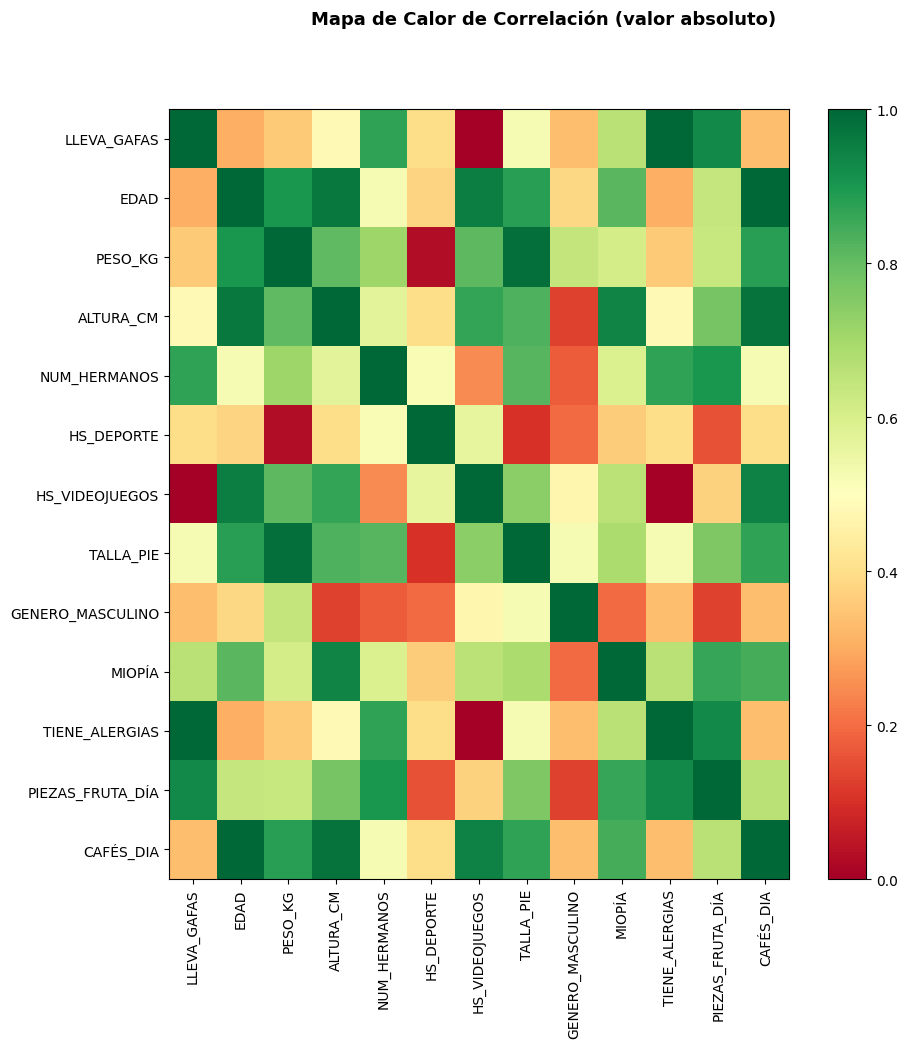

In [3]:
# PASO 3.1
def matriz_correlaciones(y, X, se_dibuja=False):
    # Calcula y dibuja la matriz de correlaciones
    # Devuelve:
    #   yX - datos concatenados
    #   yX_corr - matriz de correlaciones, correlación de Pearson entre [-1, +1]
    #   yX_abs_corr - matriz de correlaciones en valor absoluto

    yX = pd.concat([y, X], axis=1)  # Concatenar los datos de y y X en un solo DataFrame
    yX = yX.rename(columns={0: 'TARGET'})  # Cambiar el nombre de la primera columna a 'TARGET'
    
    # Calcula la matriz de correlación usando el método de Pearson y la convierte en DataFrame
    yX_corr = yX.corr(method='pearson')
    yX_abs_corr = np.abs(yX_corr)  # Convierte la matriz de correlación a valores absolutos
    
    if se_dibuja:
        plt.figure(figsize=(10, 10))
        plt.imshow(yX_abs_corr, cmap='RdYlGn', interpolation='none', aspect='auto')
        plt.colorbar()
        
        # Configura las etiquetas de los ejes
        plt.xticks(range(len(yX_abs_corr)), yX_abs_corr.columns, rotation='vertical')
        plt.yticks(range(len(yX_abs_corr)), yX_abs_corr.columns)
        
        # Título del gráfico
        plt.suptitle('Mapa de Calor de Correlación (valor absoluto)', fontsize=13, fontweight='bold')
        plt.show()

    return yX, yX_corr, yX_abs_corr

# Calcular y visualizar la matriz de correlación de los datos de entrenamiento
yX, yX_corr, yX_abs_corr = matriz_correlaciones(y_train, X_train_0, se_dibuja=True)

In [4]:
# PASO 3.2

# Reducción univariada
CORRELACION_MIN = 0.1

# Ordenamos características por su correlación con el target
s_corr_target = yX_abs_corr[TARGET]
s_corr_target_sort = s_corr_target.sort_values(ascending=False)

# Solo usamos columnas con correlación > 0.1
s_low_correlation_ftrs = s_corr_target_sort[s_corr_target_sort <= CORRELACION_MIN]
print(f"Eliminadas {len(s_low_correlation_ftrs)} predictoras:")
for i, v in enumerate(s_low_correlation_ftrs):
    print(
        f"  {i:3d}, {np.round(v, DISPLAY_PRECISION)}, {s_low_correlation_ftrs.index[i]}"
    )

s_corr_target_sort = s_corr_target_sort[s_corr_target_sort > CORRELACION_MIN]
print(f"Quedan {len(s_corr_target_sort)-1} características correlacionadas:")
for i, v in enumerate(s_corr_target_sort):
    ftr = s_corr_target_sort.index[i]
    if ftr == TARGET:
        continue
    print(f"  {i:3d}, {np.round(v, DISPLAY_PRECISION)}, {ftr}")

Eliminadas 1 predictoras:
    0, 0.0, HS_VIDEOJUEGOS
Quedan 11 características correlacionadas:
    1, 1.0, TIENE_ALERGIAS
    2, 0.9272, PIEZAS_FRUTA_DÍA
    3, 0.8704, NUM_HERMANOS
    4, 0.664, MIOPÍA
    5, 0.5222, TALLA_PIE
    6, 0.4807, ALTURA_CM
    7, 0.3961, HS_DEPORTE
    8, 0.3574, PESO_KG
    9, 0.3333, CAFÉS_DIA
   10, 0.3333, GENERO_MASCULINO
   11, 0.3065, EDAD


In [5]:
# PASO 3.3

# Eliminar a los de baja correlación del anterior
li_X1_cols = list(set(s_corr_target_sort.index) - set(s_low_correlation_ftrs.index))
li_X1_cols.remove(TARGET)

# Colinealidad
CORRELACION_MAX = 0.8
X1 = X_train_0[li_X1_cols]
yX1, yX_corr1, yX_abs_corr1 = matriz_correlaciones(y_train, X1, se_dibuja=False)

# Obtener todas las parejas de predictores
Xcorr1 = yX_abs_corr1.iloc[1:, 1:]
s_parejas = Xcorr1.unstack()
print("s_parejas.shape:", s_parejas.shape)
s_parejas = np.round(s_parejas, decimals=DISPLAY_PRECISION)
s_parejas_sorted = s_parejas.sort_values(ascending=False)
s_parejas_sorted = s_parejas_sorted[
    (s_parejas_sorted != 1) & (s_parejas_sorted > CORRELACION_MAX)
]

# Convertir una lista de nombres
li_corr_parejas = s_parejas_sorted.index.tolist()
print("len(li_corr_parejas):", len(li_corr_parejas))
print("li_corr_parejas[:10]:", li_corr_parejas[:10])

s_parejas.shape: (121,)
len(li_corr_parejas): 36
li_corr_parejas[:10]: [('CAFÉS_DIA', 'EDAD'), ('EDAD', 'CAFÉS_DIA'), ('PESO_KG', 'TALLA_PIE'), ('TALLA_PIE', 'PESO_KG'), ('CAFÉS_DIA', 'ALTURA_CM'), ('ALTURA_CM', 'CAFÉS_DIA'), ('ALTURA_CM', 'EDAD'), ('EDAD', 'ALTURA_CM'), ('MIOPÍA', 'ALTURA_CM'), ('ALTURA_CM', 'MIOPÍA')]


In [6]:
# PASO 3.4

# Calcular lista de predictoras a eliminar
li_remove_parejas = []
li_remove_puntuaciones = []
for tup in li_corr_parejas:
    s0 = s_corr_target_sort.loc[tup[0]]
    s1 = s_corr_target_sort.loc[tup[1]]
    remove_predictora = tup[1] if s1 < s0 else tup[0]  # obtener la < con target
    if remove_predictora not in li_remove_parejas:
        li_remove_parejas.append(remove_predictora)
        di = {
            "var_0": tup[0],
            "var_1": tup[1],
            "coef_0": s0,
            "coef_1": s1,
            "PREDICTORA_A_QUITAR": remove_predictora,
        }
        li_remove_puntuaciones.append(OrderedDict(di))

df_remove_puntuaciones = pd.DataFrame(li_remove_puntuaciones)

# Eliminar predictoras encontradas
print("Eliminando %d predictoras (ver última columna):" % len(li_remove_parejas))
print(df_remove_puntuaciones.to_string())

li_X2_cols = list(set(li_X1_cols) - set(li_remove_parejas))
li_X2_cols.sort()
print("==== Quedan %d predictoras:" % (len(li_X2_cols)))

for i, v in enumerate(s_corr_target_sort):
    ftr = s_corr_target_sort.index[i]
    if ftr in li_X2_cols:
        print(i, np.round(v, DISPLAY_PRECISION), ftr)

Eliminando 8 predictoras (ver última columna):
            var_0             var_1  coef_0  coef_1 PREDICTORA_A_QUITAR
0       CAFÉS_DIA              EDAD  0.3333  0.3065                EDAD
1         PESO_KG         TALLA_PIE  0.3574  0.5222             PESO_KG
2       CAFÉS_DIA         ALTURA_CM  0.3333  0.4807           CAFÉS_DIA
3          MIOPÍA         ALTURA_CM  0.6640  0.4807           ALTURA_CM
4  TIENE_ALERGIAS  PIEZAS_FRUTA_DÍA  1.0000  0.9272    PIEZAS_FRUTA_DÍA
5    NUM_HERMANOS  PIEZAS_FRUTA_DÍA  0.8704  0.9272        NUM_HERMANOS
6          MIOPÍA  PIEZAS_FRUTA_DÍA  0.6640  0.9272              MIOPÍA
7    NUM_HERMANOS         TALLA_PIE  0.8704  0.5222           TALLA_PIE
==== Quedan 3 predictoras:
1 1.0 TIENE_ALERGIAS
7 0.3961 HS_DEPORTE
10 0.3333 GENERO_MASCULINO


==== Tras la reducción con parejas X2.shape: (4, 3)
Las Remaining features:
LLEVA_GAFAS         1.0000
TIENE_ALERGIAS      1.0000
HS_DEPORTE          0.3961
GENERO_MASCULINO    0.3333
Name: LLEVA_GAFAS, dtype: float64
---
Tras la reducción con parejas X3.shape: (4, 3)


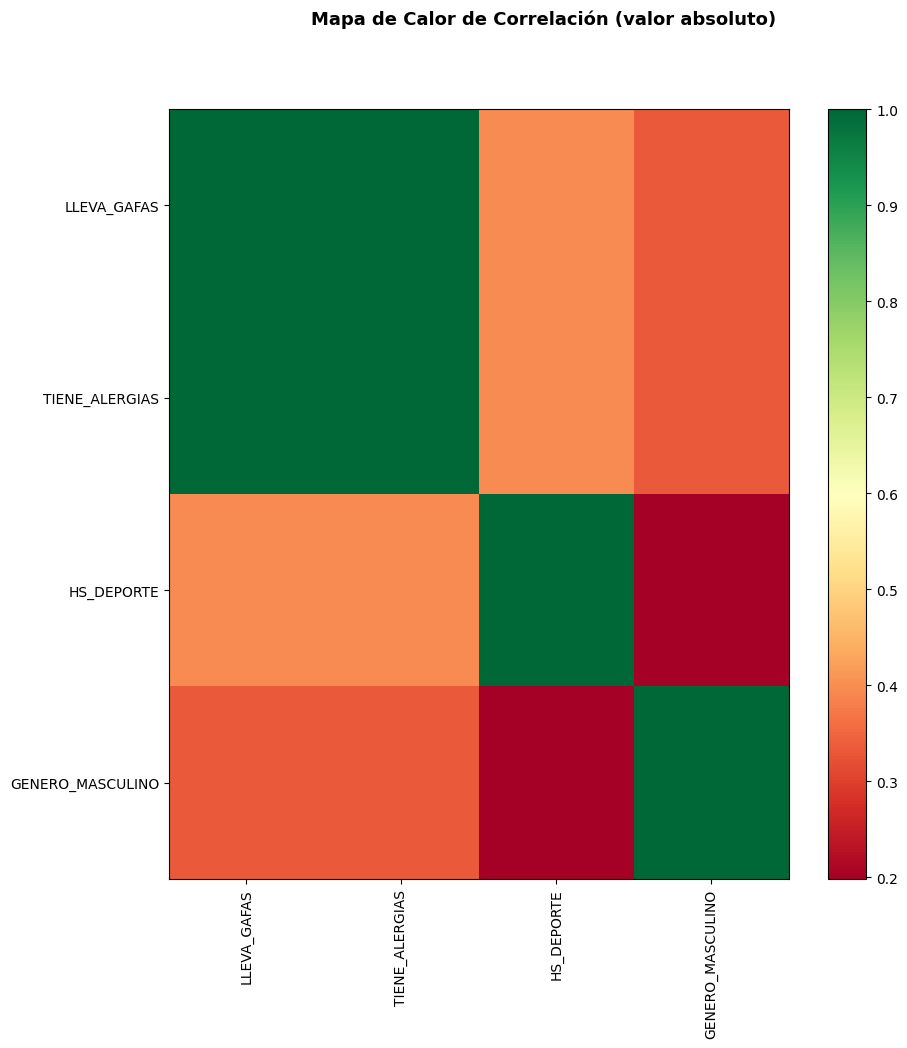

In [7]:
# PASO 3.5

# Calcula la matriz de correlaciones
X2 = X1[li_X2_cols]
print("==== Tras la reducción con parejas X2.shape:", X2.shape)
yX2, yX_corr2, yX_abs_corr2 = matriz_correlaciones(y_train, X2)
s_X3_cols = yX_abs_corr2[TARGET].sort_values(ascending=False)
li_X3_cols = s_X3_cols.index.tolist()
print("Las Remaining features:")
print(s_X3_cols)
print("---")
li_X3_cols.remove(TARGET)
X3 = X2[li_X3_cols]
print("Tras la reducción con parejas X3.shape:", X3.shape)
yX3, yX_corr3, yX_abs_corr3 = matriz_correlaciones(y_train, X3, se_dibuja=True)
X_train = X3
X_test = X_test_0[li_X3_cols]

c:\Users\davil\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:2219: UserWarning: The marginal plotting function has changed to `histplot`, which does not accept the following argument(s): rug.
  warnings.warn(msg, UserWarning)


Text(0.5, 0.98, 'Ejemplo de matriz de parejas')

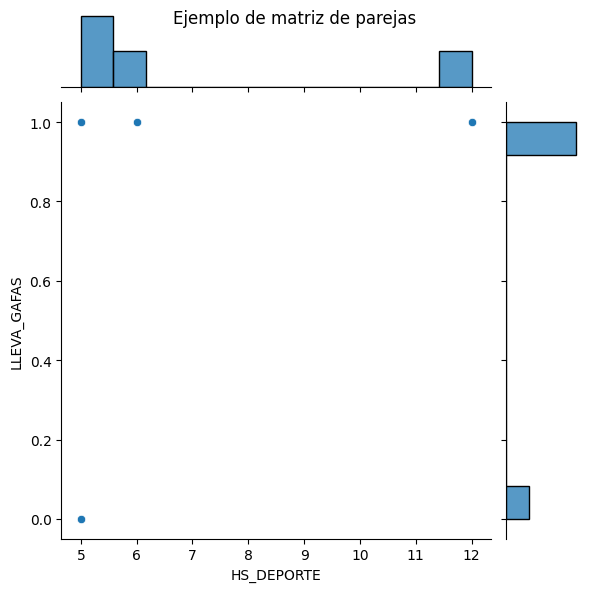

In [8]:
# PASO 3.6

sns.jointplot(
    yX3,
    x="HS_DEPORTE",
    y=TARGET,
    kind="scatter",
    marginal_kws=dict(bins=12, rug=True),
)
plt.suptitle("Ejemplo de matriz de parejas")

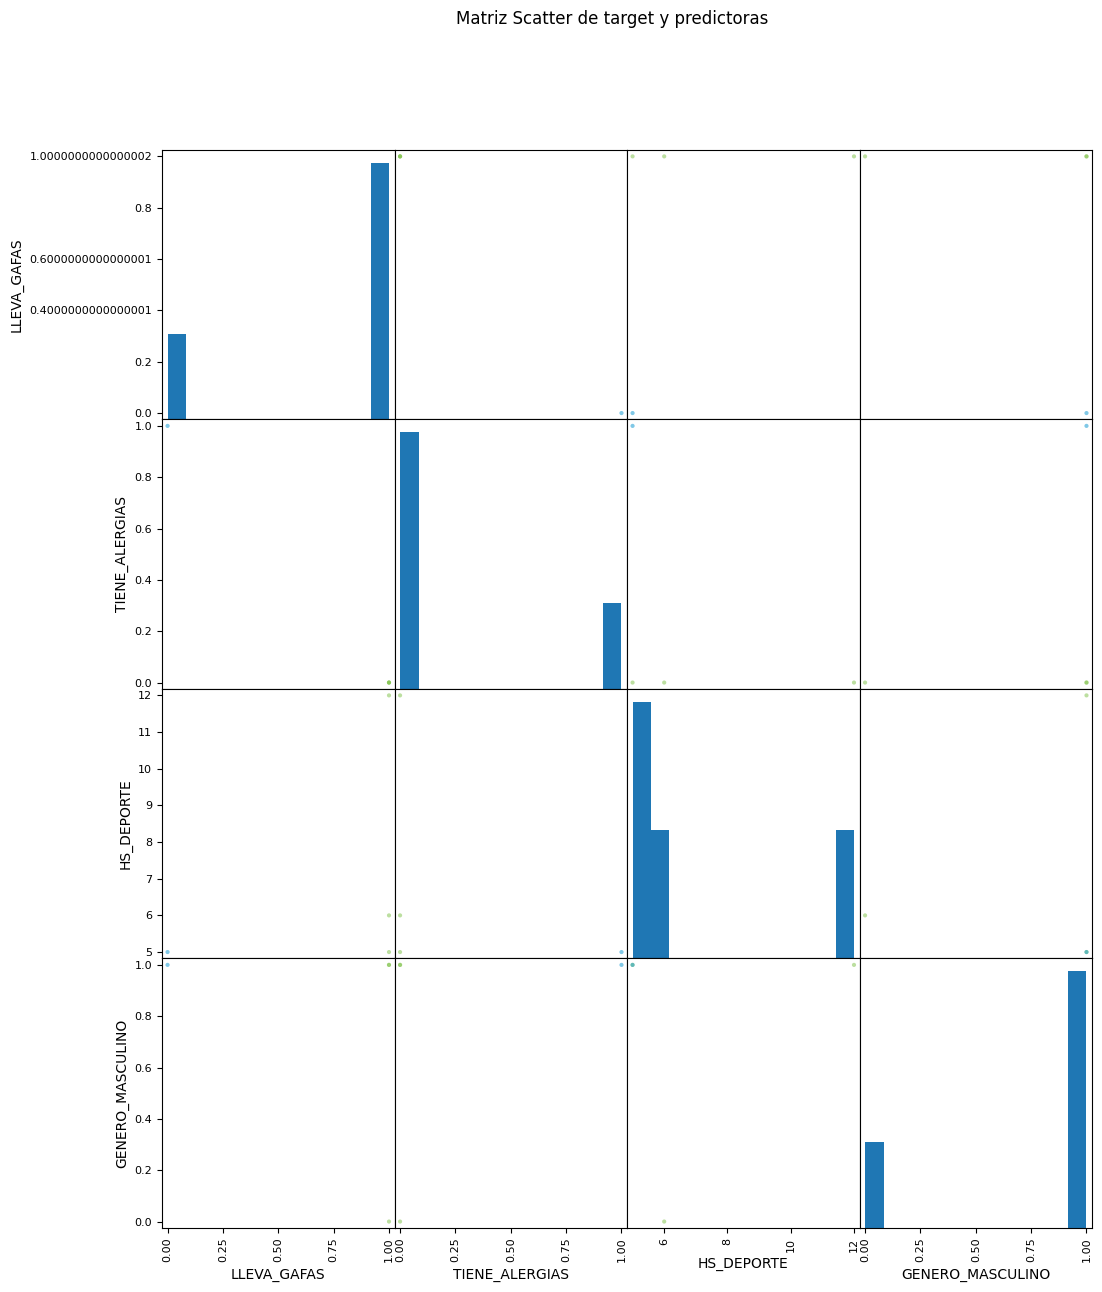

In [9]:
# PASO 3.7

mapa_colores = {0: "#0392cf", 1: "#7bc043"}  # 0(clase negativa):blue, 1(positiva):green
colores = yX3[TARGET].map(lambda x: mapa_colores.get(x))
pd.plotting.scatter_matrix(
    yX3,
    alpha=0.5,
    color=colores,
    figsize=(12, 14),
    diagonal="hist",
    hist_kwds={"bins": 12},
)
plt.suptitle("Matriz Scatter de target y predictoras")
plt.show()

In [10]:
# PASO 4.1

print(f"==== X_train.shape: {X_train.shape}, y_train.shape: {y_train.shape}")

# Distribución de clases de TARGET en train y test
val_cnts = y_train.value_counts()
print("Distribución de ejemplos positivos y negativos en train:")
print(val_cnts)
print("Porcentaje de positivos: %s" % "%.2f%%" % (100 * val_cnts[1] / len(y_train)))

print(f"==== X_test.shape: {X_test.shape}, y_test.shape: {y_test.shape}")
val_cnts = y_test.value_counts()
print("Distribución de ejemplos positivos y negativos en test:")
print(val_cnts)

print("Porcentaje de positivos: %s" % "%.2f%%" % (100 * val_cnts[1] / len(y_test)))
#print("Porcentaje de positivos: %s" % "%.2f%%" % (100 * val_cnts[1] / len(y_train)))

==== X_train.shape: (4, 3), y_train.shape: (4,)
Distribución de ejemplos positivos y negativos en train:
LLEVA_GAFAS
1    3
0    1
Name: count, dtype: int64
Porcentaje de positivos: 75.00%
==== X_test.shape: (1, 3), y_test.shape: (1,)
Distribución de ejemplos positivos y negativos en test:
LLEVA_GAFAS
0    1
Name: count, dtype: int64


KeyError: 1

In [ ]:
# PASO 4.2


def plot_2d_grid_search_heatmap(
    grid_search, grid_params, x_param, y_param, is_verbose=True
):
    """
    Dibuja un mapa de calor 2D del proceso grid search.
    Parámetros:
        grid_search: instancia de un objeto sklearn.GridSearchCV
        grid_params: diccionario de parámetros grid search
        x_param: nombre del parámetro eje-x del grid_params
        y_param: nombre del parámetro eje-y del grid_params
        is_verbose (opcional): imprime resultados

    Return:
        grid_search.best_score_: mejor puntuación encontrada
        grid_search.best_estimator_: mejor estimador encontrado
    """
    grid_params_x = grid_params[x_param]
    grid_params_y = grid_params[y_param]
    df_result = pd.DataFrame(grid_search.cv_results_)
    ar_scores = np.array(df_result.mean_test_score).reshape(
        len(grid_params_y), len(grid_params_x)
    )

    sns.heatmap(
        ar_scores,
        annot=True,
        fmt=".3f",
        xticklabels=grid_params_x,
        yticklabels=grid_params_y,
    )
    plt.suptitle("Mapa de Calor Grid Search")
    plt.xlabel(x_param)
    plt.ylabel(y_param)

    if is_verbose:
        print("\n==== grid_search.best_score_:")
        print(grid_search.best_score_)
        print()
        print("grid_search.best_estimator_:")
        print(grid_search.best_estimator_)

    plt.show()
    return grid_search.best_score_, grid_search.best_estimator_

In [ ]:
# PASO 4.3

grid_rl = {"C": [0.001, 0.01, 0.1, 1, 10, 100, 1000], "penalty": ["l1", "l2"]}
cla_rl = LogisticRegression(
    class_weight="balanced",
    dual=False,
    fit_intercept=True,
    intercept_scaling=1,
    max_iter=200,
    n_jobs=1,
    random_state=0,
    tol=0.0001,
    verbose=0,
    warm_start=False,
)

gs_rl = GridSearchCV(cla_rl, grid_rl, return_train_score=True)

# Se realizan por defecto validación cruzada de 3-fold
gs_rl.fit(X_train, y_train)  # Entrenar el modelo
best_score_rl, cla_rl = plot_2d_grid_search_heatmap(gs_rl, grid_rl, "C", "penalty")

print("==== Atributo de Clasificador de Regresión Logística:")
print(" intercept_:", cla_rl.intercept_)
print(" coef_:", cla_rl.coef_)

ValueError: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=4.

In [ ]:
# PASO 4.4

grid_gb = {"min_samples_leaf": [2, 4, 8, 16], "learning_rate": [0.001, 0.01, 0.1]}
cla_gbm = GradientBoostingClassifier(
    criterion="friedman_mse",
    init=None,
    loss="log_loss",
    max_leaf_nodes=None,
    max_features="sqrt",
    max_depth=3,
    warm_start=False,
    min_impurity_decrease=0.0,
    min_samples_split=2,
    min_weight_fraction_leaf=0.0,
    n_estimators=800,
    random_state=0,
    subsample=1.0,
    verbose=0,
)

# Por defecto usa 3-fold CV
gs_gb = GridSearchCV(cla_gbm, grid_gb, verbose=0, return_train_score=True)
gs_gb.fit(X_train, y_train)  # Entrenar modelo
best_score_gb, cla_gb = plot_2d_grid_search_heatmap(
    gs_gb, grid_gb, "min_samples_leaf", "learning_rate"
)

ValueError: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=4.

In [ ]:
# PASO 5.1

li_clas = ["cla_rl", "cla_gb"]
dfp = pd.DataFrame(index=["TARGET"], data=[y_test]).T
for s_cla in li_clas:
    print("\nMODELO: " + s_cla)
    print("---------------")
    cla = eval(s_cla)
    y_pred = cla.predict(X_test).astype(int)  # devuelve una clase decisión
    y_score = cla.predict_proba(X_test)  # devuelve el valor de probabilidad
    s_class = "%s_class" % s_cla
    s_proba = "%s_proba" % s_cla
    s_rank = "%s_rank" % s_cla
    dfp[s_class] = y_pred
    dfp[s_proba] = y_score[:, 1]
    dfp[s_rank] = dfp[s_proba].rank(ascending=1).astype(int)

    # Imprime la matriz de confusión y el informe de clasificación
    # desde sklearn.metrics importa la matriz de confusión
    # cm = confusion_matrix(y_test, y_pred)
    cm = pd.crosstab(
        y_test, y_pred, rownames=["Reality"], colnames=["Predicted"], margins=True
    )

    print(cm)

    # PASO 5.2
    print("\nInforme de Clasificadores:")
    print(classification_report(y_test, y_pred))
    if s_cla == "cla_rl":
        y_score_lr = y_score.copy()
    elif s_cla == "cla_gb":
        y_score_gb = y_score.copy()
    else:
        print("Error")
        break
    print(dfp.tail(10).to_string())


MODELO: cla_rl
---------------


NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
# PASO 5.3

RANGO_BINS = 10
rango_cols = [
    "i_bin",
    "i_min_bin",
    "i_max_bin",
    "score_min",
    "score_max",
    "bin_cnt",
    "pos_cnt",
    "pos_rate",
]
rango_cols2 = [
    "i_bin",
    "score_min",
    "score_max",
    "tnr",
    "fpr",
    "fnr",
    "tpr",
    "tn",
    "fp",
    "fn",
    "tp",
]
print(dfp.shape)
len_test = dfp.shape[0]
len_bin = int(len_test / RANGO_BINS)
for s_cla in li_clas:
    i_min_bin = 0
    i_max_bin = 0
    dfr = pd.DataFrame(columns=rango_cols)
    dfr2 = pd.DataFrame(columns=rango_cols2)
    s_class = "%s_class" % s_cla
    s_proba = "%s_proba" % s_cla
    s_rank = "%s_rank" % s_cla
    for i in range(RANGO_BINS):
        if i == RANGO_BINS - 1:
            i_max_bin = len_test
        else:
            i_max_bin += len_bin

        # Rango usado para cada bin de puntuaciones
        df_rng = dfp[(dfp[s_rank] >= i_min_bin) & (dfp[s_rank] < i_max_bin)]
        score_min = np.min(df_rng[s_proba])
        score_max = np.max(df_rng[s_proba])
        bin_cnt = df_rng.shape[0]
        pos_cnt = len(df_rng[df_rng["TARGET"] == 1])
        pos_rate = pos_cnt / bin_cnt

        # Rango usado para todos los bins hasta i_max_bin
        df_rng_0 = dfp[dfp[s_rank] < i_max_bin]
        df_rng_1 = dfp[dfp[s_rank] >= i_max_bin]

        # targets positivos (tp=true positivos, fn=false negativos)
        tp = len(df_rng_1[df_rng_1["TARGET"] == 1])
        fn = len(df_rng_0[df_rng_0["TARGET"] == 1])
        pos = tp + fn
        tpr = tp / pos
        fnr = 1 - tpr

        # Targets Negativos
        tn = len(df_rng_0[df_rng_0["TARGET"] == 0])
        fp = len(df_rng_1[df_rng_1["TARGET"] == 0])
        neg = tn + fp
        fpr = fp / neg
        tnr = 1 - fpr

        # Hacer el dataframe para resumen de estadísticas por bin
        row = [
            i,
            i_min_bin,
            i_max_bin,
            score_min,
            score_max,
            bin_cnt,
            pos_cnt,
            pos_rate,
        ]
        dfr.loc[i] = row

        # Hacer el dataframe para las estadísticas ROC por bin
        row2 = [i, score_min, score_max, tnr, fpr, fnr, tpr, tn, fp, fn, tp]
        dfr2.loc[i] = row2

        i_min_bin = i_max_bin  # Preparar la siguiente iteración

    if s_cla == "cla_rl":
        dfr_lr = dfr.copy()
        dfr2_lr = dfr2.copy()
    elif s_cla == "cla_gb":
        dfr_gb = dfr.copy()
        dfr2_gb = dfr2.copy()
    else:
        print("Error")
        break

print("==== Resultados de contadores estadísticos positivos por bin")
print("Estadísticas de Regresión Logística:")
print(dfr_lr.to_string())
print()
print("Estadísticas de GBM:")
print(dfr_gb.to_string())
print()
print("...")
print("Estadísticas globales en el test set:")
pos_cnt = len(dfp[dfp["TARGET"] == 1])
pos_rate = pos_cnt / len_test
print("pos_cnt", pos_cnt)
print("total filas", len_test)
print("pos_rate", pos_rate)

(114, 7)
==== Resultados de contadores estadísticos positivos por bin
Estadísticas de Regresión Logística:
   i_bin  i_min_bin  i_max_bin   score_min   score_max  bin_cnt  pos_cnt  pos_rate
0    0.0        0.0       11.0  1.1330e-06  9.2893e-05     10.0      0.0    0.0000
1    1.0       11.0       22.0  1.5464e-04  7.4713e-04     11.0      0.0    0.0000
2    2.0       22.0       33.0  9.3717e-04  3.1325e-03     11.0      0.0    0.0000
3    3.0       33.0       44.0  4.2099e-03  9.2474e-03     11.0      0.0    0.0000
4    4.0       44.0       55.0  1.1241e-02  3.5592e-02     11.0      1.0    0.0909
5    5.0       55.0       66.0  4.1207e-02  3.6121e-01     11.0      2.0    0.1818
6    6.0       66.0       77.0  4.3717e-01  9.6296e-01     11.0      6.0    0.5455
7    7.0       77.0       88.0  9.7479e-01  9.9908e-01     11.0     11.0    1.0000
8    8.0       88.0       99.0  9.9930e-01  9.9983e-01     11.0     11.0    1.0000
9    9.0       99.0      114.0  9.9997e-01  1.0000e+00     15.0

C:\Users\davil\AppData\Local\Temp\ipykernel_19140\3379999549.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


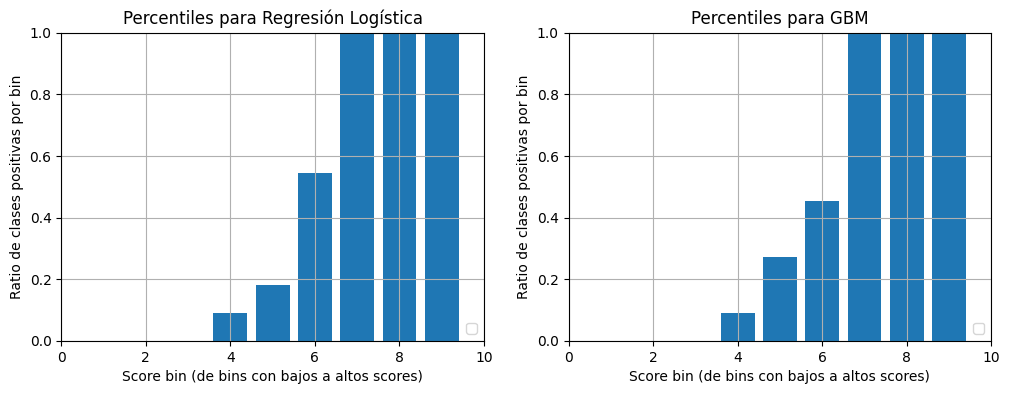

In [ ]:
# PASO 5.4

s_titulos = ["Regresión Logística", "GBM"]
plt.figure(figsize=(12, 4))
for i, s_cla in enumerate(li_clas):
    s_titulo = s_titulos[i]
    if s_cla == "cla_rl":
        dfr = dfr_lr
        dfr2 = dfr2_lr
    elif s_cla == "cla_gb":
        dfr = dfr_gb
        dfr2 = dfr2_gb
    else:
        print("Error")
        break

    plt.subplot(1, 2, i + 1)
    plt.bar(dfr["i_bin"], dfr["pos_rate"])
    plt.title("Percentiles para " + s_titulo)
    plt.grid()
    plt.xlabel("Score bin (de bins con bajos a altos scores)")
    plt.ylabel("Ratio de clases positivas por bin")
    plt.legend(loc="lower right")
    plt.xlim([0, RANGO_BINS])
    plt.ylim([0.0, 1])

plt.show()

==== Resultados de estadísticas ROC por bin
Estadísticas de Regresión Logística:
   i_bin   score_min   score_max     tnr     fpr     fnr     tpr    tn    fp    fn    tp
0    0.0  1.1330e-06  9.2893e-05  0.1493  0.8507  0.0000  1.0000  10.0  57.0   0.0  47.0
1    1.0  1.5464e-04  7.4713e-04  0.3134  0.6866  0.0000  1.0000  21.0  46.0   0.0  47.0
2    2.0  9.3717e-04  3.1325e-03  0.4776  0.5224  0.0000  1.0000  32.0  35.0   0.0  47.0
3    3.0  4.2099e-03  9.2474e-03  0.6418  0.3582  0.0000  1.0000  43.0  24.0   0.0  47.0
4    4.0  1.1241e-02  3.5592e-02  0.7910  0.2090  0.0213  0.9787  53.0  14.0   1.0  46.0
5    5.0  4.1207e-02  3.6121e-01  0.9254  0.0746  0.0638  0.9362  62.0   5.0   3.0  44.0
6    6.0  4.3717e-01  9.6296e-01  1.0000  0.0000  0.1915  0.8085  67.0   0.0   9.0  38.0
7    7.0  9.7479e-01  9.9908e-01  1.0000  0.0000  0.4255  0.5745  67.0   0.0  20.0  27.0
8    8.0  9.9930e-01  9.9983e-01  1.0000  0.0000  0.6596  0.3404  67.0   0.0  31.0  16.0
9    9.0  9.9997e-01  1.0000e

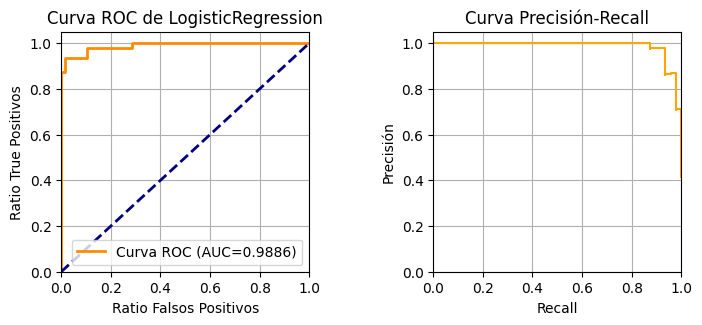



MODELO: cla_gb
---------------


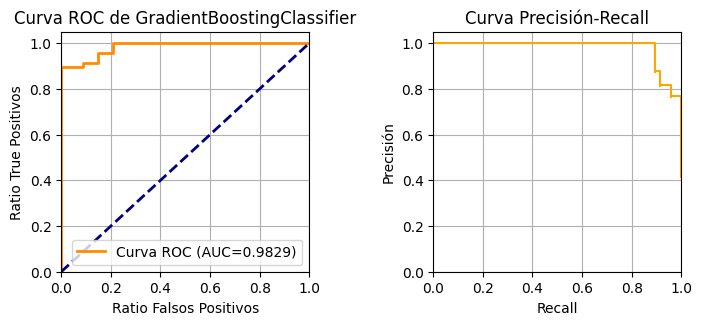

In [ ]:
# PASO 5.5

print("==== Resultados de estadísticas ROC por bin")
print("Estadísticas de Regresión Logística:")
print(dfr2_lr.to_string())
print()
print("Estadísticas de GBM:")
print(dfr2_gb.to_string())


def plot_roc_y_precision_recall(y_true, y_score, modelo=None):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)  # Calcula ROC y AUC usando FPR y TPR
    precision, recall, _ = precision_recall_curve(y_true, y_score)

    plt.figure(figsize=(8, 3))
    plt.subplot(1, 2, 1)
    lw = 2
    plt.plot(
        fpr, tpr, color="darkorange", lw=lw, label="Curva ROC (AUC=%.4f)" % roc_auc
    )
    plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("Ratio Falsos Positivos")
    plt.ylabel("Ratio True Positivos")
    titulo = "Curva ROC"
    if modelo != None:
        titulo = titulo + " de " + modelo.__class__.__name__
    plt.title(titulo)
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.step(recall, precision, color="orange", where="post")
    plt.xlabel("Recall")
    plt.ylabel("Precisión")
    plt.ylim([0.0, 1.05])
    plt.xlim([0.0, 1.0])
    plt.title("Curva Precisión-Recall")
    plt.grid(True)
    plt.subplots_adjust(0.125, 0.1, 0.9, 0.9, 0.5, 0.2)
    plt.show()


for s_cla in li_clas:
    print("\nMODELO: " + s_cla)
    print("---------------")
    cla = eval(s_cla)
    y_pred = cla.predict(X_test).astype(int)
    y_score = cla.predict_proba(X_test)
    plot_roc_y_precision_recall(y_test, y_score[:, 1], cla)
    print()